# Starter Notebook: Qwen 2B LoRA for Text-to-SVG (Kaggle)

This starter is built from the resources in `contest_docs`:
- Data resources: `contest_docs/03_Data_Design.md`
- Baseline and starter guidance: `contest_docs/05_Baselines_and_Starter_Notebooks.md`
- Kaggle implementation notes: `contest_docs/06_Kaggle_Implementation_Guide.md`

Goal: provide a practical scaffold for Qwen-2B-class fine-tuning + submission generation.

## Referenced Data and Docs

### Dataset resources from `contest_docs/03_Data_Design.md`
- `OmniSVG/MMSVG-Icon`
- `xingxm/SVGX-Core-250k`
- `xingxm/SVGX-SFT-1M` (recommended subset: `SVGX_SFT_GEN_51k.json`)
- `nyuuzyou/svgfind`
- `starvector/svg-icons`
- `thesantatitan/deepseek-svg-dataset`
- `InternSVG/SArena` (evaluation benchmark)

### Qwen 2B fine-tuning references from `contest_docs/05` and `contest_docs/06`
- Unsloth Qwen fine-tune docs: https://unsloth.ai/docs/models/qwen3.5/fine-tune
- Qwen3.5-2B Vision notebook: https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Qwen3_5_(2B)_Vision.ipynb

Note: this notebook is written as a reusable starter. You may need to adjust exact model IDs and column names to match the latest upstream datasets.

In [ ]:
# Uncomment in a fresh Kaggle notebook environment.
#%pip install -q unsloth datasets trl transformers accelerate peft bitsandbytes pandas lxml

In [ ]:
#%pip install lxml

In [ ]:
#pip install matplotlib

In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

CUDA available: True
NVIDIA GeForce RTX 5070 Ti


In [2]:
import os
import re
import time
import random
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments
from peft import ( LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training, PeftModel, )
from trl import SFTTrainer

from lxml import etree
from copy import deepcopy
#from datasets import concatenate_datasets, load_dataset

W0331 20:18:55.559000 11044 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Torch: {torch.__version__}")
print(torch.cuda.get_device_name(0))
print(f"CUDA available: {torch.cuda.is_available()}")

Torch: 2.10.0+cu130
NVIDIA GeForce RTX 5070 Ti
CUDA available: True


In [4]:
#these are models that can be tested in the future
#Qwen2.5-Coder-1.5B-Instruct-bnb-4bit
#"Qwen/Qwen2.5-Coder-1.5B-Instruct"
#Qwen/Qwen3-4B-Instruct-2507

In [5]:
# Core training config.
# Keep runtime targets in line with contest_docs guidance (roughly <= 6-8 hours training).

MODEL_ID = "Qwen/Qwen3-4B-Instruct-2507"

CONFIG = {
    "max_seq_length": 2048,
    "num_train_epochs": 2,
    "per_device_train_batch_size": 2,
    "gradient_accumulation_steps": 8,
    "learning_rate": 2e-4,
    "warmup_ratio": 0.05,
    "weight_decay": 0.01,
    "logging_steps": 20,
    "save_steps": 200,
    "eval_steps": 100,
    "eval_ratio": 0.05,
    "output_dir": "./svg_lora_adapter",
    #"debug_train_rows": 5000,   # set to None or comment out for full training
    "submission_path": "./submission.csv",
}

CONFIG

{'max_seq_length': 2048,
 'num_train_epochs': 2,
 'per_device_train_batch_size': 2,
 'gradient_accumulation_steps': 8,
 'learning_rate': 0.0002,
 'warmup_ratio': 0.05,
 'weight_decay': 0.01,
 'logging_steps': 20,
 'save_steps': 200,
 'eval_steps': 100,
 'eval_ratio': 0.05,
 'output_dir': './svg_lora_adapter',
 'submission_path': './submission.csv'}

In [6]:
TRAIN_PATH = "kaggle/input/competitions/dl-spring-2026-svg-generation/train.csv"
TEST_PATH = "kaggle/input/competitions/dl-spring-2026-svg-generation/test.csv"
SAMPLE_SUB_PATH = "kaggle/input/competitions/dl-spring-2026-svg-generation/sample_submission.csv"

In [7]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_sub_df = pd.read_csv(SAMPLE_SUB_PATH)

print(train_df.shape)
print(test_df.shape)
print(sample_sub_df.shape)

print(train_df.head())
print(test_df.head())

(50000, 3)
(1000, 2)
(1000, 2)
                                           id  \
0            fd61e324e0cec5c11f337d0bfe2858c8   
1            999b3d4d5a860725bf9528910b5612f3   
2            1aaa84517819c25f783ae1c0cb337fc5   
3            919a7da8bd44dc7781dbe87383a268cc   
4  thesantatitan_deepseek-svg-dataset_0000581   

                                              prompt  \
0  The image features two orange squares with a m...   
1  A simple smiley face with a wide open mouth an...   
2  The image features a black-outlined icon of a ...   
3  The image displays a black icon with a photo-l...   
4  Generate svg code for an image that looks like...   

                                                 svg  
0  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
1  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
2  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
3  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
4  <svg width="24" height="24" viewBox="0 0 24 24...  
       

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

ALLOWED_TAGS = {
    "svg", "g", "path", "rect", "circle", "ellipse",
    "line", "polyline", "polygon",
    "defs", "use", "symbol", "clipPath", "mask",
    "linearGradient", "radialGradient", "stop",
    "text", "tspan", "title", "desc", "style",
    "pattern", "marker", "filter"
}

SVG_REGEX = re.compile(r"<svg[\s\S]*?</svg>", re.IGNORECASE)

SYSTEM_PROMPT = (
    "generate only valid SVG markup with Canvas size 256 × 256 pixels and at most 16,000 characters with a single root <svg> element. "
    "Max path count must be less than 256. "
    "Only allowed SVG tags and keep the output concise. "
)

In [9]:
# =========================
# SVG cleaning/quantization config
# =========================
ENABLE_SVG_CLEANING = True
REMOVE_EXTRA_ATTRS = True
COORD_PRECISION = 1

ALLOWED_ATTRS = [
    'd', 'fill', 'stroke', 'stroke-width',
    'viewBox', 'xmlns', 'width', 'height',
    'cx', 'cy', 'r', 'rx', 'ry',
    'x', 'y', 'x1', 'y1', 'x2', 'y2',
    'points', 'transform',
    'opacity', 'fill-opacity', 'stroke-opacity',
    'stroke-linecap', 'stroke-linejoin', 'stroke-miterlimit',
    'font-size', 'font-family', 'text-anchor',
    'offset', 'stop-color', 'stop-opacity',
    'id', 'clip-path', 'mask', 'href'
]

# 哪些属性里的数字要做 1 位小数量化
NUMERIC_ATTRS_TO_QUANTIZE = {
    "d", "viewBox", "width", "height",
    "cx", "cy", "r", "rx", "ry",
    "x", "y", "x1", "y1", "x2", "y2",
    "points", "transform",
    "stroke-width", "opacity", "fill-opacity", "stroke-opacity",
    "font-size", "offset"
}

NUMBER_PATTERN = re.compile(r"[-+]?(?:\d*\.\d+|\d+)")

def quantize_number_str(num_str: str, precision: int = COORD_PRECISION) -> str:
    """
    Quantize a numeric string to fixed precision, while removing trailing zeros.
    Examples:
      12.0000 -> 12
      8.349   -> 8.3   (precision=1)
      -0.04   -> 0
    """
    try:
        val = float(num_str)
        rounded = round(val, precision)

        # avoid '-0'
        if abs(rounded) < (10 ** (-precision)) / 2:
            rounded = 0.0

        if float(rounded).is_integer():
            return str(int(rounded))

        out = f"{rounded:.{precision}f}".rstrip("0").rstrip(".")
        return out if out != "-0" else "0"
    except Exception:
        return num_str

def quantize_numbers_in_text(text: str, precision: int = COORD_PRECISION) -> str:
    if not isinstance(text, str) or not text:
        return text
    return NUMBER_PATTERN.sub(lambda m: quantize_number_str(m.group(0), precision), text)

def local_name(tag_or_attr: str) -> str:
    """
    Convert namespaced tag/attr to local name.
    Example: '{http://www.w3.org/2000/svg}path' -> 'path'
    """
    try:
        return etree.QName(tag_or_attr).localname
    except Exception:
        if isinstance(tag_or_attr, str) and "}" in tag_or_attr:
            return tag_or_attr.split("}", 1)[1]
        return str(tag_or_attr)

def clean_single_svg(svg_string: str) -> str:
    """
    Safe-ish SVG cleaning:
    1) optionally remove non-whitelisted attrs
    2) quantize coordinates / numeric attrs to 1 decimal
    3) serialize back to compact one-line XML

    If parsing fails, fall back to original SVG string.
    """
    if not isinstance(svg_string, str) or not svg_string.strip():
        return svg_string

    try:
        parser = etree.XMLParser(remove_blank_text=True, recover=True)
        root = etree.fromstring(svg_string.encode("utf-8"), parser=parser)

        # must have svg root
        if local_name(root.tag) != "svg":
            return svg_string

        for elem in root.iter():
            # ---- remove extra attrs ----
            if REMOVE_EXTRA_ATTRS:
                attrs_to_remove = []
                for attr_key in list(elem.attrib.keys()):
                    attr_name = local_name(attr_key)
                    if attr_name not in ALLOWED_ATTRS:
                        attrs_to_remove.append(attr_key)

                for attr_key in attrs_to_remove:
                    del elem.attrib[attr_key]

            # ---- quantize numeric attrs ----
            for attr_key in list(elem.attrib.keys()):
                attr_name = local_name(attr_key)

                if attr_name in NUMERIC_ATTRS_TO_QUANTIZE:
                    elem.attrib[attr_key] = quantize_numbers_in_text(
                        elem.attrib[attr_key],
                        precision=COORD_PRECISION
                    )

        cleaned = etree.tostring(
            root,
            encoding="unicode",
            method="xml",
            pretty_print=False
        )

        return cleaned.replace("\n", "").replace("\r", "").strip()

    except Exception:
        return svg_string

def summarize_svg_cleaning(df_before: pd.DataFrame, df_after: pd.DataFrame, sample_n: int = 1000):
    """
    Lightweight report for compression sanity-check.
    Token stats use the current tokenizer already loaded in notebook.
    """
    old_char_lens = df_before["svg"].astype(str).map(len)
    new_char_lens = df_after["svg"].astype(str).map(len)

    print("=" * 50)
    print("SVG CLEANING REPORT")
    print("=" * 50)
    print(f"Rows: {len(df_after)}")
    print(f"Avg char length (old): {old_char_lens.mean():.2f}")
    print(f"Avg char length (new): {new_char_lens.mean():.2f}")
    print(f"Char compression: {(1 - new_char_lens.mean() / old_char_lens.mean()) * 100:.2f}%")

    n = min(sample_n, len(df_after))
    sample_idx = np.random.RandomState(SEED).choice(len(df_after), size=n, replace=False)

    old_token_lens = []
    new_token_lens = []

    for i in sample_idx:
        old_svg = df_before.iloc[i]["svg"]
        new_svg = df_after.iloc[i]["svg"]

        old_token_lens.append(len(tokenizer(old_svg, add_special_tokens=False)["input_ids"]))
        new_token_lens.append(len(tokenizer(new_svg, add_special_tokens=False)["input_ids"]))

    old_token_lens = np.array(old_token_lens)
    new_token_lens = np.array(new_token_lens)

    print(f"Avg token length old (sample {n}): {old_token_lens.mean():.2f}")
    print(f"Avg token length new (sample {n}): {new_token_lens.mean():.2f}")
    print(f"Token compression (sample): {(1 - new_token_lens.mean() / old_token_lens.mean()) * 100:.2f}%")
    print("=" * 50)

In [10]:
test_svg = '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#303C42" fill-opacity="1.0"  filling="0" d="M133.90625 183.90625 L13.4375 183.90625 C6.40625 183.90625 0.78125 178.28125 0.78125 171.25 L0.78125 28.75 C0.78125 21.71875 6.40625 16.09375 13.4375 16.09375 L133.90625 16.09375 C140.9375 16.09375 146.5625 21.71875 146.5625 28.75 L146.5625 171.25 C146.5625 178.28125 140.9375 183.90625 133.90625 183.90625 Z M13.4375 22.34375 C9.84375 22.34375 7.03125 25.15625 7.03125 28.75 L7.03125 171.25 C7.03125 174.84375 9.84375 177.65625 13.4375 177.65625 L133.90625 177.65625 C137.5 177.65625 140.3125 174.84375 140.3125 171.25 L140.3125 28.75 C140.3125 25.15625 137.5 22.34375 133.90625 22.34375 L13.4375 22.34375 Z"></path> <path fill="#303C42" fill-opacity="1.0"  filling="0" d="M143.4375 147.1875 C142.8125 147.1875 142.1875 147.03125 141.5625 146.5625 C140.78125 145.9375 140.3125 145.0 140.3125 144.0625 L140.3125 45.937503814697266 C140.3125 44.375003814697266 141.40625 43.124996185302734 142.96875 42.812503814697266 C146.71875 42.1875 150.46875 41.875 154.0625 41.875 C170.78125 41.875 184.375 47.96875 192.34375 59.0625 C199.84375 69.53125 201.40625 83.28125 196.40625 97.65625 C189.21875 118.90625 168.75 138.28125 144.53125 146.875 C144.0625 147.1875 143.75 147.1875 143.4375 147.1875 Z M146.5625 48.593746185302734 L146.5625 139.53125 C167.34375 130.9375 184.21875 114.0625 190.46875 95.78125 C194.6875 83.4375 193.4375 71.71875 187.1875 62.8125 C179.375 51.875 164.6875 46.5625 146.5625 48.593746185302734 Z M67.96875 141.875 L29.6875 141.875 C24.6875 141.875 20.625 137.8125 20.625 132.8125 L20.625 75.3125 C20.625 70.3125 24.6875 66.25 29.6875 66.25 L67.96875 66.25 C72.96875 66.25 77.03125 70.3125 77.03125 75.3125 L77.03125 132.8125 C77.03125 137.8125 72.96875 141.875 67.96875 141.875 Z M29.6875 69.375 C26.40625 69.375 23.75 72.03125 23.75 75.3125 L23.75 132.8125 C23.75 136.09375 26.40625 138.75 29.6875 138.75 L67.96875 138.75 C71.25 138.75 73.90625 136.09375 73.90625 132.8125 L73.90625 75.3125 C73.90625 72.03125 71.25 69.375 67.96875 69.375 L29.6875 69.375 Z"></path> <path fill="#303C42" fill-opacity="1.0"  filling="0" d="M48.90625 105.625 C42.343746185302734 105.625 36.874996185302734 100.15625 36.874996185302734 93.59375 C36.874996185302734 87.03125 42.343746185302734 81.5625 48.90625 81.5625 C55.46875 81.5625 60.9375 87.03125 60.9375 93.59375 C60.9375 100.15625 55.46875 105.625 48.90625 105.625 Z M48.90625 84.6875 C44.0625 84.6875 39.999996185302734 88.75 39.999996185302734 93.59375 C39.999996185302734 98.4375 44.0625 102.5 48.90625 102.5 C53.750003814697266 102.5 57.8125 98.4375 57.8125 93.59375 C57.8125 88.59375 53.750003814697266 84.6875 48.90625 84.6875 Z"></path> <path fill="#303C42" fill-opacity="1.0"  filling="0" d="M48.90625 84.6875 C47.96875 84.6875 47.34375 84.0625 47.34375 83.125 L47.34375 19.21875 C47.34375 18.28125 47.96875 17.65625 48.90625 17.65625 C49.843753814697266 17.65625 50.46875 18.28125 50.46875 19.21875 L50.46875 83.125 C50.46875 83.90625 49.6875 84.6875 48.90625 84.6875 Z"></path></svg>'

tokens = tokenizer(test_svg, add_special_tokens=False)["input_ids"]
print(f"Token count: {len(tokens)}")
print(f"Char count: {len(test_svg)}")

Token count: 2835
Char count: 3110


In [11]:
# =========================
# Apply SVG cleaning BEFORE token-length statistics / sampling
# =========================
if ENABLE_SVG_CLEANING:
    print("Applying SVG cleaning to train_df['svg'] ...")

    train_df_before_clean = train_df[["id", "prompt", "svg"]].copy()
    train_df["svg_raw"] = train_df["svg"]   # optional backup
    train_df["svg"] = train_df["svg"].apply(clean_single_svg)

    summarize_svg_cleaning(train_df_before_clean, train_df, sample_n=1000)

    # quick sanity check on a few rows
    for idx in [0, 1, 2]:
        if idx < len(train_df):
            print(f"\n--- Sample {idx} ---")
            print("OLD:", train_df_before_clean.iloc[idx]["svg"][:300])
            print("NEW:", train_df.iloc[idx]["svg"][:300])

print("svg token length...")
train_df["svg_token_len"] = train_df["svg"].apply(
    lambda s: len(tokenizer(s, add_special_tokens=False)["input_ids"])
)

print(train_df["svg_token_len"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

Applying SVG cleaning to train_df['svg'] ...
SVG CLEANING REPORT
Rows: 50000
Avg char length (old): 2524.28
Avg char length (new): 1086.23
Char compression: 56.97%
Avg token length old (sample 1000): 2339.28
Avg token length new (sample 1000): 908.04
Token compression (sample): 61.18%

--- Sample 0 ---
OLD: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#FF6A00" fill-opacity="1.0"  filling="0" d="M93.30000305175781 21.20000457763672 L93.30000305175781 80.4000015258789 L21.20000457763672 80.4000015258789 L21.20000457763672 179.600006103
NEW: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 200 200" height="200px" width="200px"><path fill="#FF6A00" fill-opacity="1" d="M93.3 21.2 L93.3 80.4 L21.2 80.4 L21.2 179.6 L120.4 179.6 L120.4 107.1 L179.1 107.1 L179.1 21.2 L93.3 21.2 Z M113.8 172.9 L27.9 172.9 L27.9 87.1 L113.7 87.1 L113.7 172.

--- Sample 1 ---
OLD: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.

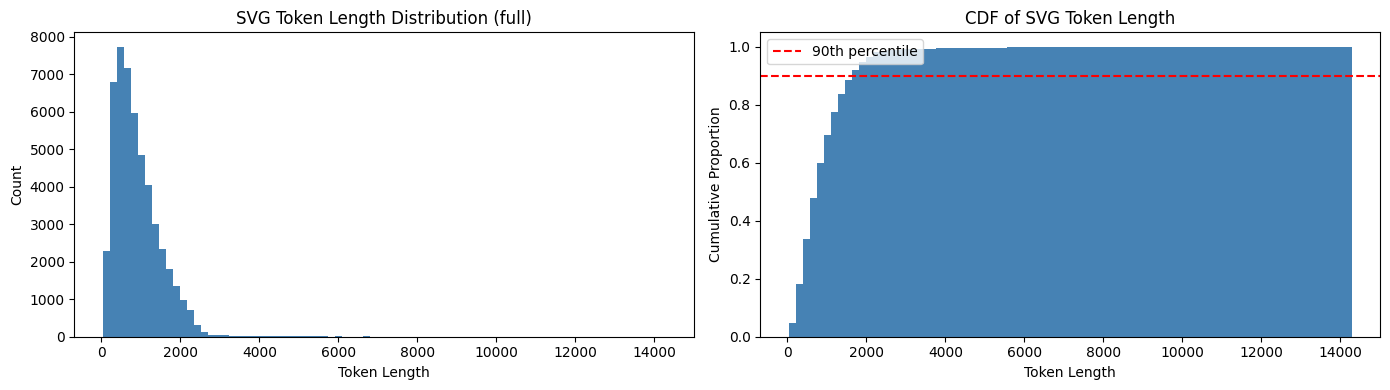

p10=290  p25=462  p50=769  p75=1207  p90=1704  p99=2770


In [12]:
# 可视化分布
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df["svg_token_len"], bins=80, color="steelblue", edgecolor="none")
axes[0].set_title("SVG Token Length Distribution (full)")
axes[0].set_xlabel("Token Length")
axes[0].set_ylabel("Count")

axes[1].hist(train_df["svg_token_len"], bins=80, color="steelblue", edgecolor="none", cumulative=True, density=True)
axes[1].set_title("CDF of SVG Token Length")
axes[1].set_xlabel("Token Length")
axes[1].set_ylabel("Cumulative Proportion")
axes[1].axhline(0.9, color="red", linestyle="--", label="90th percentile")
axes[1].legend()

plt.tight_layout()
plt.show()

p10  = train_df["svg_token_len"].quantile(0.10)
p25  = train_df["svg_token_len"].quantile(0.25)
p50  = train_df["svg_token_len"].quantile(0.50)
p75  = train_df["svg_token_len"].quantile(0.75)
p90  = train_df["svg_token_len"].quantile(0.90)
p99  = train_df["svg_token_len"].quantile(0.99)
print(f"p10={p10:.0f}  p25={p25:.0f}  p50={p50:.0f}  p75={p75:.0f}  p90={p90:.0f}  p99={p99:.0f}")

In [13]:
# train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

In [14]:
TARGET_N = 8000

SAFE_SVG_MAXLEN = 1600

pool_df = train_df[train_df["svg_token_len"] <= SAFE_SVG_MAXLEN].copy()

print("Pool size after safe length filter:", len(pool_df))
print(pool_df["svg_token_len"].describe())

# =========================
# 2) 按 token length 等宽分桶
# =========================
# 这里用等宽桶，得到的长度分布会更“均匀”
N_BINS = 8

min_len = pool_df["svg_token_len"].min()
max_len = pool_df["svg_token_len"].max()

bin_edges = np.linspace(min_len, max_len + 1e-6, N_BINS + 1)

pool_df["len_bin"] = pd.cut(
    pool_df["svg_token_len"],
    bins=bin_edges,
    include_lowest=True,
    duplicates="drop"
)

print("\nCounts per bin before sampling:")
print(pool_df["len_bin"].value_counts().sort_index())


groups = [g for _, g in pool_df.groupby("len_bin", observed=True) if len(g) > 0]
num_groups = len(groups)

base_n = TARGET_N // num_groups
sampled_parts = []
leftover_parts = []

for g in groups:
    take_n = min(base_n, len(g))
    sampled = g.sample(n=take_n, random_state=SEED)
    sampled_parts.append(sampled)
    leftover_parts.append(g.drop(sampled.index))

sampled_df = pd.concat(sampled_parts, axis=0)

remaining_n = TARGET_N - len(sampled_df)

if remaining_n > 0:
    leftover_pool = pd.concat(leftover_parts, axis=0)
    extra = leftover_pool.sample(
        n=min(remaining_n, len(leftover_pool)),
        random_state=SEED
    )
    sampled_df = pd.concat([sampled_df, extra], axis=0)


sampled_df = sampled_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nFinal sampled size:", len(sampled_df))
print("\nCounts per bin after sampling:")
print(sampled_df["len_bin"].value_counts().sort_index())

print("\nSampled token length stats:")
print(sampled_df["svg_token_len"].describe())


train_df_small = sampled_df.copy()

Pool size after safe length filter: 43864
count    43864.000000
mean       740.710993
std        381.604188
min         28.000000
25%        427.000000
50%        689.000000
75%       1024.000000
max       1600.000000
Name: svg_token_len, dtype: float64

Counts per bin before sampling:
len_bin
(27.999, 224.5]     2765
(224.5, 421.0]      7969
(421.0, 617.5]      8374
(617.5, 814.0]      7489
(814.0, 1010.5]     5954
(1010.5, 1207.0]    4949
(1207.0, 1403.5]    3562
(1403.5, 1600.0]    2802
Name: count, dtype: int64

Final sampled size: 8000

Counts per bin after sampling:
len_bin
(27.999, 224.5]     1000
(224.5, 421.0]      1000
(421.0, 617.5]      1000
(617.5, 814.0]      1000
(814.0, 1010.5]     1000
(1010.5, 1207.0]    1000
(1207.0, 1403.5]    1000
(1403.5, 1600.0]    1000
Name: count, dtype: int64

Sampled token length stats:
count    8000.000000
mean      818.300500
std       444.987143
min        28.000000
25%       421.750000
50%       814.500000
75%      1207.250000
max      16

In [15]:
train_df = train_df_small

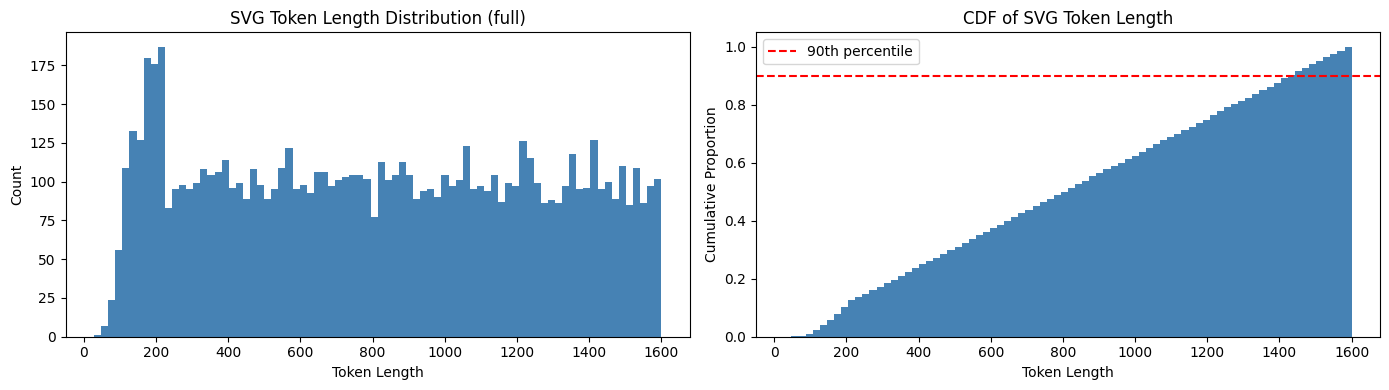

p10=203  p25=422  p50=814  p75=1207  p90=1438  p99=1585


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df["svg_token_len"], bins=80, color="steelblue", edgecolor="none")
axes[0].set_title("SVG Token Length Distribution (full)")
axes[0].set_xlabel("Token Length")
axes[0].set_ylabel("Count")

axes[1].hist(train_df["svg_token_len"], bins=80, color="steelblue", edgecolor="none", cumulative=True, density=True)
axes[1].set_title("CDF of SVG Token Length")
axes[1].set_xlabel("Token Length")
axes[1].set_ylabel("Cumulative Proportion")
axes[1].axhline(0.9, color="red", linestyle="--", label="90th percentile")
axes[1].legend()

plt.tight_layout()
plt.show()

p10  = train_df["svg_token_len"].quantile(0.10)
p25  = train_df["svg_token_len"].quantile(0.25)
p50  = train_df["svg_token_len"].quantile(0.50)
p75  = train_df["svg_token_len"].quantile(0.75)
p90  = train_df["svg_token_len"].quantile(0.90)
p99  = train_df["svg_token_len"].quantile(0.99)
print(f"p10={p10:.0f}  p25={p25:.0f}  p50={p50:.0f}  p75={p75:.0f}  p90={p90:.0f}  p99={p99:.0f}")

In [18]:
def format_svg_sample(prompt: str, svg_code: str) -> str:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": svg_code},
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )


In [19]:
from datasets import Dataset

In [20]:


# if CONFIG["debug_train_rows"] is not None:
#     train_df = train_df.iloc[:CONFIG["debug_train_rows"]].copy()

eval_n = int(len(train_df) * CONFIG["eval_ratio"])
eval_df = train_df.iloc[:eval_n].copy()
train_df_small = train_df.iloc[eval_n:].copy()

print("Train rows:", len(train_df_small))
print("Eval rows:", len(eval_df))

# Build text column for SFT
train_df_small["text"] = train_df_small.apply(
    lambda row: format_svg_sample(row["prompt"], row["svg"]),
    axis=1,
)
eval_df["text"] = eval_df.apply(
    lambda row: format_svg_sample(row["prompt"], row["svg"]),
    axis=1,
)

train_ds = Dataset.from_pandas(train_df_small[["text"]], preserve_index=False)
eval_ds = Dataset.from_pandas(eval_df[["text"]], preserve_index=False)

print(train_ds[0]["text"][:500])

Train rows: 7600
Eval rows: 400
<|im_start|>system
generate only valid SVG markup with Canvas size 256 × 256 pixels and at most 16,000 characters with a single root <svg> element. Max path count must be less than 256. Only allowed SVG tags and keep the output concise. <|im_end|>
<|im_start|>user
The image features a single black circular shape positioned centrally against a white background, with a thin black vertical line extending downward from the bottom center of the circle.<|im_end|>
<|im_start|>assistant
<svg xmlns="http


In [21]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading base model for training...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float16,
    trust_remote_code=True,
)

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Loading base model for training...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

trainable params: 33,030,144 || all params: 4,055,498,240 || trainable%: 0.8145


In [22]:
from trl import SFTTrainer, SFTConfig

In [23]:
#SFTConfig instead of SFTTrainer

training_args = SFTConfig(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["num_train_epochs"],
    per_device_train_batch_size=CONFIG["per_device_train_batch_size"],
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
    learning_rate=CONFIG["learning_rate"],
    warmup_ratio=CONFIG["warmup_ratio"],
    weight_decay=CONFIG["weight_decay"],
    logging_steps=CONFIG["logging_steps"],
    eval_steps=CONFIG["eval_steps"],
    save_steps=CONFIG["save_steps"],
    save_total_limit=2,
    eval_strategy="steps",
    save_strategy="steps",
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    report_to="none",
    seed=SEED,
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},

    
    dataset_text_field="text",
    max_length=CONFIG["max_seq_length"],   #  max_seq_length
    packing=False,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=tokenizer,
)

train_result = trainer.train()
train_result

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/7600 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/7600 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/7600 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,0.417834,0.454927,0.452259,1456362.000000,0.848066
200,0.421507,0.440734,0.428452,2919293.000000,0.851111
300,0.401997,0.432549,0.428203,4384650.000000,0.854051
400,0.409943,0.427644,0.422349,5860503.000000,0.855551
500,0.382041,0.423501,0.398670,7360381.000000,0.856980
600,0.383653,0.419108,0.407255,8828290.000000,0.857818
700,0.367634,0.416459,0.404553,10281488.000000,0.858786
800,0.367266,0.414353,0.404393,11752171.000000,0.859604
900,0.384431,0.413623,0.403210,13215348.000000,0.859660


TrainOutput(global_step=950, training_loss=0.4074947959498355, metrics={'train_runtime': 28642.5017, 'train_samples_per_second': 0.531, 'train_steps_per_second': 0.033, 'total_flos': 3.9297929082448896e+17, 'train_loss': 0.4074947959498355, 'entropy': 0.3697220617905259, 'num_tokens': 13965480.0, 'mean_token_accuracy': 0.8744700014591217, 'epoch': 2.0})

In [24]:
os.makedirs(CONFIG["output_dir"], exist_ok=True)
trainer.save_model(CONFIG["output_dir"])
tokenizer.save_pretrained(CONFIG["output_dir"])

print(f"Saved adapter + tokenizer to: {CONFIG['output_dir']}")

Saved adapter + tokenizer to: ./svg_lora_adapter


In [25]:
# Option (a): Load adapter
print("Loading base model for inference...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float16,
    trust_remote_code=True,
)

print("Loading LoRA adapter for inference...")
model = PeftModel.from_pretrained(base_model, CONFIG["output_dir"])

#reset just for safty
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "left"

model.eval()
print("Model loaded for inference.")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading base model for inference...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading LoRA adapter for inference...
Model loaded for inference.


In [81]:
# =========================================================
def build_messages(user_prompt: str):
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]

def generate_svg(prompt: str, max_new_tokens: int = 1400) -> str:
    messages = build_messages(prompt)

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,   # deterministic first
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            use_cache=True,
        )

    # Only decode newly generated tokens
    new_token_ids = generated_ids[0][model_inputs.input_ids.shape[1]:]
    response = tokenizer.decode(new_token_ids, skip_special_tokens=True)

    svg = extract_svg(response)
    svg = sanitize_svg(svg)

    if not is_valid_svg(svg):
        svg = fallback_svg()

    return svg

#Disclose AI tooling, I used ChatGPT to learn how to see progress bar
def generate_svg_batch(prompts, batch_size=4, max_new_tokens=1024):
    outputs = []
    stats = {"no_svg_match": 0, "invalid_svg": 0, "fallback_used": 0, "truncated_like": 0}

    with tqdm(total=len(prompts), desc="Generating SVG rows") as pbar:
        for i in range(0, len(prompts), batch_size):
            batch_prompts = prompts[i:i + batch_size]

            batch_texts = []
            for p in batch_prompts:
                messages = build_messages(p)
                text = tokenizer.apply_chat_template(
                    messages, tokenize=False, add_generation_prompt=True,
                )
                batch_texts.append(text)

            inputs = tokenizer(
                batch_texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=CONFIG["max_seq_length"],
            ).to(model.device)

            # ✅ 记录input总长度（含padding），用于切片
            input_seq_len = inputs["input_ids"].shape[1]

            with torch.no_grad():
                generated = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=True,          # ✅ 加一点随机性，避免退化
                    temperature=0.3,
                    pad_token_id=tokenizer.eos_token_id,
                    eos_token_id=tokenizer.eos_token_id,
                    use_cache=True,
                )

            for j in range(len(batch_prompts)):
                # ✅ 正确切片：从input总长度之后开始
                new_token_ids = generated[j][input_seq_len:]
                response = tokenizer.decode(new_token_ids, skip_special_tokens=True)

                if "<svg" in response and "</svg>" not in response:
                    stats["truncated_like"] += 1

                raw_svg = extract_svg(response)

                if not raw_svg:
                    stats["no_svg_match"] += 1
                    stats["fallback_used"] += 1
                    outputs.append(fallback_svg())
                else:
                    raw_svg = sanitize_svg(raw_svg)
                    if not is_valid_svg(raw_svg):
                        stats["invalid_svg"] += 1
                        stats["fallback_used"] += 1
                        outputs.append(fallback_svg())
                    else:
                        outputs.append(raw_svg)

                pbar.update(1)  # ✅ 移到最外层，每个样本都更新

    return outputs, stats

In [82]:

def extract_svg(text: str) -> str:
    m = SVG_REGEX.search(text)
    return m.group(0).strip() if m else ""

def fallback_svg():
    return (
        '<svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256">'
        '<rect width="256" height="256" fill="white"/>'
        '<circle cx="128" cy="128" r="48" fill="black"/>'
        '</svg>'
    )

def is_valid_svg(svg_text: str) -> bool:
    if not svg_text:
        return False

    # 长度限制
    if len(svg_text) > 16000:
        return False

    # path 数量限制
    if svg_text.count("<path") > 256:
        return False

    try:
        root = ET.fromstring(svg_text)
    except ET.ParseError:
        return False

    # root 必须是 svg
    root_tag = root.tag.split("}")[-1]
    if root_tag != "svg":
        return False

    width = root.attrib.get("width")
    height = root.attrib.get("height")
    viewbox = root.attrib.get("viewBox")

    def to_float(x):
        try:
            return float(str(x).replace("px", ""))
        except:
            return None

    w = to_float(width)
    h = to_float(height)

    if w is not None and h is not None:
        if w != 256 or h != 256:
            return False

    elif viewbox:
        parts = viewbox.strip().split()
        if len(parts) == 4:
            vb_w = to_float(parts[2])
            vb_h = to_float(parts[3])
            if vb_w != 256 or vb_h != 256:
                return False
        else:
            return False
    else:
        return False

    for elem in root.iter():
        tag = elem.tag.split("}")[-1]
        if tag not in ALLOWED_TAGS:
            return False

        for attr, val in elem.attrib.items():
            attr_l = attr.lower()
            val_l = str(val).lower()

            if attr_l.startswith("on"):
                return False

            if "javascript:" in val_l:
                return False
            if "http://" in val_l or "https://" in val_l:
                return False

    return True

# def sanitize_svg(svg_text: str) -> str:
#     """
#     Light post-processing.
#     Keep it simple for now. If invalid, caller can fallback.
#     """
#     if not svg_text:
#         return ""
#     svg_text = svg_text.strip()
#     return svg_text

def sanitize_svg(svg_text: str) -> str:
    if not svg_text:
        return ""

    svg_text = svg_text.strip()

    try:
        root = ET.fromstring(svg_text)

        if root.tag.split("}")[-1] != "svg":
            return ""

        def to_float(x):
            try:
                return float(str(x).replace("px", ""))
            except:
                return None

        viewbox = root.attrib.get("viewBox", "").strip()
        vb_parts = viewbox.split()

        old_min_x = old_min_y = 0.0
        old_w = old_h = None

        if len(vb_parts) == 4:
            old_min_x = to_float(vb_parts[0])
            old_min_y = to_float(vb_parts[1])
            old_w = to_float(vb_parts[2])
            old_h = to_float(vb_parts[3])

        if old_w is None or old_h is None:
            old_w = to_float(root.attrib.get("width"))
            old_h = to_float(root.attrib.get("height"))
            old_min_x = 0.0
            old_min_y = 0.0

        target = 256.0
        old_children = list(root)

        for child in list(root):
            root.remove(child)

        # 不要再手动 set xmlns
        root.set("width", "256")
        root.set("height", "256")
        root.set("viewBox", "0 0 256 256")

        if old_w is not None and old_h is not None and old_w > 0 and old_h > 0:
            sx = target / old_w
            sy = target / old_h

            if abs(old_min_x) > 1e-9 or abs(old_min_y) > 1e-9:
                transform = f"translate({-old_min_x:g},{-old_min_y:g}) scale({sx:g},{sy:g})"
            else:
                transform = f"scale({sx:g},{sy:g})"

            g = ET.Element("g")
            g.set("transform", transform)

            for child in old_children:
                g.append(child)

            root.append(g)
        else:
            for child in old_children:
                root.append(child)

        return ET.tostring(root, encoding="unicode")

    except Exception:
        return svg_text

In [83]:
def generate_svg_debug(prompt: str, max_new_tokens: int = 1024):
    messages = build_messages(prompt)

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            use_cache=True,
        )

    new_token_ids = generated_ids[0][model_inputs.input_ids.shape[1]:]
    response = tokenizer.decode(new_token_ids, skip_special_tokens=True)

    raw_svg = extract_svg(response)
    sanitized_svg = sanitize_svg(raw_svg) if raw_svg else ""

    print("=" * 80)
    print("FULL RAW RESPONSE:")
    print(response[:3000])   # 先看前 3000 字符
    print("=" * 80)
    print("EXTRACTED SVG:")
    print(raw_svg[:3000] if raw_svg else "[NO SVG MATCH]")
    print("=" * 80)
    print("SANITIZED SVG:")
    print(sanitized_svg[:3000] if sanitized_svg else "[EMPTY AFTER SANITIZE]")
    print("=" * 80)

    print("raw_svg exists:", bool(raw_svg))
    print("sanitized valid:", is_valid_svg(sanitized_svg) if sanitized_svg else False)

    if not sanitized_svg or not is_valid_svg(sanitized_svg):
        print(">>> FALLBACK USED")
        return fallback_svg(), response, raw_svg, sanitized_svg

    return sanitized_svg, response, raw_svg, sanitized_svg

In [84]:
pred_svg, response, raw_svg, sanitized_svg = generate_svg_debug("A simple line drawing of a trash can icon.")

FULL RAW RESPONSE:
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 200 200" height="200px" width="200px"><path fill="#333333" fill-opacity="1" d="M162.5 18.8 L37.5 18.8 C25.6 18.8 16.7 27.7 16.7 39.6 L16.7 160.4 C16.7 172.3 25.6 181.2 37.5 181.2 L162.5 181.2 C174.4 181.2 183.3 172.3 183.3 160.4 L183.3 39.6 C183.3 27.7 174.4 18.8 162.5 18.8 Z M37.5 31.2 C31.2 31.2 25 37.4 25 43.8 L25 156.2 C25 162.6 31.2 168.8 37.5 168.8 L162.5 168.8 C168.8 168.8 175 162.6 175 156.2 L175 43.8 C175 37.4 168.8 31.2 162.5 31.2 L37.5 31.2 Z"/><path fill="#333333" fill-opacity="1" d="M100 125 L100 141.7 C100 145.4 97.1 148.3 93.4 148.3 L66.7 148.3 C63 148.3 60 145.4 60 141.7 L60 125 C60 121.3 63 118.3 66.7 118.3 L93.4 118.3 C97.1 118.3 100 121.3 100 125 Z M100 108.3 L100 125 C100 128.7 97.1 131.7 93.4 131.7 L66.7 131.7 C63 131.7 60 128.7 60 125 L60 108.3 C60 104.6 63 101.7 66.7 101.7 L93.4 101.7 C97.1 101.7 100 104.6 100 108.3 Z M100 91.7 L100 108.3 C100 112 97.1 115 93.4 115 L66.7 115 C63 115 60 112 60

In [62]:
def has_complete_svg(s: str) -> bool:
    if not isinstance(s, str):
        return False
    s = s.strip()
    return s.startswith("<svg") and s.endswith("</svg>")

print("complete svg ratio:", train_df["svg"].map(has_complete_svg).mean())

complete svg ratio: 0.999875


In [75]:
test_prompt = "A simple line drawing of a trash can icon."
pred_svg = generate_svg(test_prompt)
print(pred_svg[:500])
print("Valid SVG:", is_valid_svg(pred_svg))

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 256 256" height="256" width="256"><g transform="scale(1.28,1.28)"><path fill="#333333" fill-opacity="1" d="M162.5 18.8 L37.5 18.8 C25.6 18.8 16.7 27.7 16.7 39.6 L16.7 160.4 C16.7 172.3 25.6 181.2 37.5 181.2 L162.5 181.2 C174.4 181.2 183.3 172.3 183.3 160.4 L183.3 39.6 C183.3 27.7 174.4 18.8 162.5 18.8 Z M37.5 31.2 C31.2 31.2 25 37.4 25 43.8 L25 156.2 C25 162.6 31.2 168.8 37.5 168.8 L162.5 168.8 C168.8 168.8 175 162.6 175 156.2 L175 43.8 C175 3
Valid SVG: True


In [76]:
print(pred_svg[:])

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 256 256" height="256" width="256"><g transform="scale(1.28,1.28)"><path fill="#333333" fill-opacity="1" d="M162.5 18.8 L37.5 18.8 C25.6 18.8 16.7 27.7 16.7 39.6 L16.7 160.4 C16.7 172.3 25.6 181.2 37.5 181.2 L162.5 181.2 C174.4 181.2 183.3 172.3 183.3 160.4 L183.3 39.6 C183.3 27.7 174.4 18.8 162.5 18.8 Z M37.5 31.2 C31.2 31.2 25 37.4 25 43.8 L25 156.2 C25 162.6 31.2 168.8 37.5 168.8 L162.5 168.8 C168.8 168.8 175 162.6 175 156.2 L175 43.8 C175 37.4 168.8 31.2 162.5 31.2 L37.5 31.2 Z" /><path fill="#333333" fill-opacity="1" d="M100 125 L100 141.7 C100 145.4 97.1 148.3 93.4 148.3 L66.7 148.3 C63 148.3 60 145.4 60 141.7 L60 125 C60 121.3 63 118.3 66.7 118.3 L93.4 118.3 C97.1 118.3 100 121.3 100 125 Z M100 108.3 L100 125 C100 128.7 97.1 131.7 93.4 131.7 L66.7 131.7 C63 131.7 60 128.7 60 125 L60 108.3 C60 104.6 63 101.7 66.7 101.7 L93.4 101.7 C97.1 101.7 100 104.6 100 108.3 Z M100 91.7 L100 108.3 C100 112 97.1 115 93.4 115 L66.7 115 C63 115

In [77]:
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

In [ ]:
#Testing on a small set

small_prompts = test_df["prompt"].tolist()[:20]
t0 = time.time()
_ = generate_svg_batch(small_prompts, batch_size=4, max_new_tokens=1024)
print("Minutes for 20 rows:", (time.time() - t0) / 60)

In [ ]:
# Submission generation scaffold: expects Kaggle prompt file with columns `id,prompt`.
#TEST_PROMPTS_PATH = "/kaggle/input/svg-test-public-prompts/test_prompts.csv"
SUBMISSION_PATH = CONFIG["submission_path"]

rows = []
invalid_count = 0
t0 = time.time()

prompts = test_df["prompt"].tolist()
ids = test_df["id"].tolist()

pred_svgs, stats = generate_svg_batch(prompts, batch_size=4, max_new_tokens=1024)
print(stats)
for id_, svg in zip(ids, pred_svgs):
    if not is_valid_svg(svg):
        invalid_count += 1
        svg = fallback_svg()
    rows.append({"id": id_, "svg": svg})



Generating SVG rows:   0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
sub_df = pd.DataFrame(rows)
sub_df.to_csv(SUBMISSION_PATH, index=False)

elapsed_min = (time.time() - t0) / 60
print(f"Saved: {SUBMISSION_PATH}")
print(f"Rows: {len(sub_df)}")
print(f"Invalid/fallback count: {invalid_count}")
print(f"Runtime (minutes): {elapsed_min:.2f}")
print(sub_df.head())

In [ ]:
import shutil

zip_base = "./svg_lora_adapter"
if os.path.exists(CONFIG["output_dir"]):
    shutil.make_archive(zip_base, "zip", CONFIG["output_dir"])
    print("Zipped adapter folder:", zip_base + ".zip")

In [ ]:
import shutil

dst = os.path.expanduser("~/Downloads/submission.csv")
shutil.copy("submission.csv", dst)

print("Saved to:", dst)

## Notes

- Keep a fixed seed, runtime logs, and invalid-generation counts (required by `contest_docs/05`).
- If you use Kaggle-packaged datasets (`svg-train-public`, `svg-test-public-prompts`, `svg-utils`), swap paths into the loading cells.
- For stricter alignment with Unsloth templates, copy the latest prompt-formatting snippets from the official Qwen3.5-2B notebook linked above.